# Этап 3 — Предсказание: реальное или нереальное блюдо

**Задача:** graph classification — отличить настоящий рецепт от «фейкового» (ингредиенты перемешаны из разных блюд).

**Baseline:** плотность связей в графе ингредиентов `I` + логистическая регрессия.

**GraphSAGE:** эмбеддинг рецепта через двудольный граф рецепт–ингредиент, бинарный классификатор.

**Интерпретация:** для фейковых рецептов — пары ингредиентов **без ребра** в `I` (несовместимость).

**Вывод:** названия ингредиентов **на русском**.

In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from ingredient_ru import ru, ru_list

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
from gnn_graph_classification import (
    incompatible_pairs,
    make_fake_recipes,
    train_graphsage_validity,
)

OUT = Path('output_graphs')
DATA = Path('full_dataset.csv')
if not DATA.exists():
    DATA = Path('data_sample.csv')
SEED = 42

print('Готово')

Готово


## 3.1 Загрузка графа и рецептов

In [2]:
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')
ing_set = set(I.nodes())

df = pd.read_csv(DATA, nrows=8000, usecols=['NER'])

recipes = []
for s in df['NER']:
    try:
        ings = [x.strip().lower() for x in ast.literal_eval(s) if isinstance(x, str)]
        ings = [x for x in ings if x in ing_set]
        if len(ings) >= 3:
            recipes.append(ings)
    except Exception:
        pass

print(f'Рецептов: {len(recipes):,}')

Рецептов: 7,807


## 3.2 Признак «плотность связей» и метки

**Реальные** — рецепты из датасета. **Фейковые** — ~50% ингредиентов заменены случайными из графа (имитация «смешали из разных блюд» → мало связей в `I`).

In [3]:
def edge_density(ings):
    pairs = 0
    edges = 0
    for i in range(len(ings)):
        for j in range(i + 1, len(ings)):
            pairs += 1
            if I.has_edge(ings[i], ings[j]):
                edges += 1
    return edges / pairs if pairs else 0.0


X_real = np.array([[edge_density(r), len(r)] for r in recipes])
y_real = np.ones(len(recipes))

# фейковые: ~50% ингредиентов заменены случайными (из других «блюд»)
fake = make_fake_recipes(recipes, ingredient_pool=list(ing_set), mix_ratio=0.5, seed=SEED)

X_fake = np.array([[edge_density(r), len(r)] for r in fake])
y_fake = np.zeros(len(fake))

X = np.vstack([X_real, X_fake])
y = np.concatenate([y_real, y_fake])
print('Пример реального:', ru_list(recipes[0][:6]))
print('  плотность связей =', round(edge_density(recipes[0]), 3))
print('Пример фейкового:', ru_list(fake[0][:6]))
print('  плотность связей =', round(edge_density(fake[0]), 3))

Пример реального: ['коричневый сахар', 'молоко', 'ваниль', 'орехи', 'сливочное масло']
  плотность связей = 1.0
Пример фейкового: ['сливочное масло', 'коричневый сахар', 'орехи', np.str_('orange soda'), np.str_('grain rice')]
  плотность связей = 0.6


## 3.3 Обучение и оценка

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=500)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)

print(f'Точность: {accuracy_score(y_te, pred):.3f}')
print(classification_report(y_te, pred, target_names=['нереальное', 'реальное']))

Точность: 0.967
              precision    recall  f1-score   support

  нереальное       0.96      0.97      0.97      1562
    реальное       0.97      0.96      0.97      1561

    accuracy                           0.97      3123
   macro avg       0.97      0.97      0.97      3123
weighted avg       0.97      0.97      0.97      3123



## 3.4 GraphSAGE (graph classification)

In [5]:
all_recipes = recipes + fake
y_all = np.concatenate([y_real, y_fake])

gs_result = train_graphsage_validity(
    all_recipes, y_all, I=I, hidden=64, epochs=50, seed=SEED,
)

print('GraphSAGE (real vs fake):')
print(f'  Accuracy: {gs_result.accuracy:.3f}')
print(f'  F1:       {gs_result.f1:.3f}')
print(f'  AUC:      {gs_result.auc:.3f}')

GraphSAGE (real vs fake):
  Accuracy: 0.886
  F1:       0.894
  AUC:      0.952


## 3.5 Сравнение baseline и GraphSAGE

,модель,accuracy,AUC
0,LogReg (плотность связей),0.967019,0.991195
1,GraphSAGE,0.886327,0.951714


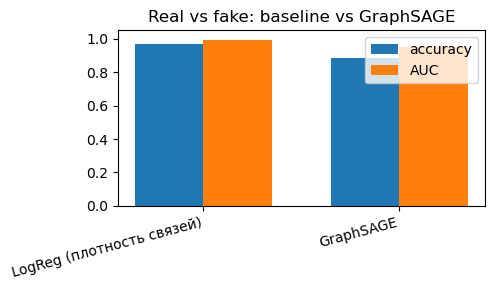

In [6]:
baseline_auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

cmp = pd.DataFrame([
    {'модель': 'LogReg (плотность связей)', 'accuracy': accuracy_score(y_te, pred), 'AUC': baseline_auc},
    {'модель': 'GraphSAGE', 'accuracy': gs_result.accuracy, 'AUC': gs_result.auc},
])
display(cmp)

fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(len(cmp))
w = 0.35
ax.bar(x - w/2, cmp['accuracy'], w, label='accuracy')
ax.bar(x + w/2, cmp['AUC'], w, label='AUC')
ax.set_xticks(x)
ax.set_xticklabels(cmp['модель'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Real vs fake: baseline vs GraphSAGE')
plt.tight_layout()
plt.savefig(OUT / 'dish_validity_compare.png', dpi=120)
plt.show()

## 3.6 Интерпретация: несовместимые пары в фейковых рецептах

Для фейкового рецепта показываем пары ингредиентов, которые **никогда не встречались вместе** в реальных рецептах (нет ребра в графе `I`).

In [7]:
print('Примеры фейковых рецептов и «странные» пары ингредиентов:\n')
for i in range(3):
    r = fake[i]
    bad = incompatible_pairs(r, I)
    print(f'Фейк #{i+1}: {ru_list(r[:8])}')
    print(f'  плотность связей = {edge_density(r):.3f}')
    if bad:
        show = bad[:5]
        pairs_ru = [f'{ru(a)} + {ru(b)}' for a, b in show]
        print(f'  несовместимые пары ({len(bad)} всего): {", ".join(pairs_ru)}')
    print()

Примеры фейковых рецептов и «странные» пары ингредиентов:

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', np.str_('orange soda'), np.str_('grain rice')]
  плотность связей = 0.600
  несовместимые пары (4 всего): сливочное масло + orange soda, орехи + orange soda, орехи + grain rice, orange soda + grain rice

Фейк #2: ['говядина', 'сметана', np.str_('lemonade mix'), np.str_('coconut instant pudding')]
  плотность связей = 0.167
  несовместимые пары (5 всего): говядина + lemonade mix, говядина + coconut instant pudding, сметана + lemonade mix, сметана + coconut instant pudding, lemonade mix + coconut instant pudding

Фейк #3: ['перец', np.str_('garlic powder'), 'сливочное масло', np.str_('savoy'), np.str_("'s white chocolate"), np.str_('chop suey vegetables')]
  плотность связей = 0.333
  несовместимые пары (10 всего): перец + savoy, перец + 's white chocolate, garlic powder + savoy, garlic powder + 's white chocolate, garlic powder + chop suey vegetables



## 3.7 График baseline (плотность связей)

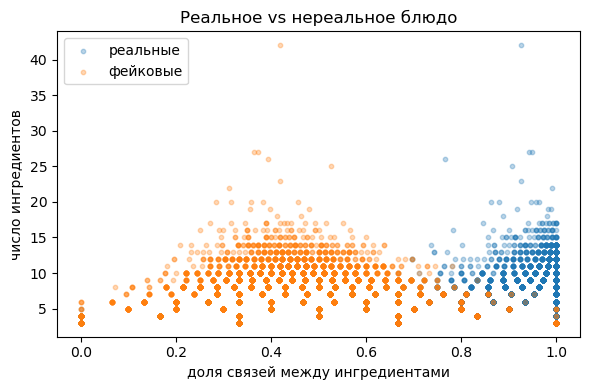

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(X_real[:,0], X_real[:,1], alpha=0.3, s=10, label='реальные')
plt.scatter(X_fake[:,0], X_fake[:,1], alpha=0.3, s=10, label='фейковые')
plt.xlabel('доля связей между ингредиентами')
plt.ylabel('число ингредиентов')
plt.legend()
plt.title('Реальное vs нереальное блюдо')
plt.tight_layout()
plt.savefig(OUT / 'dish_validity.png', dpi=120)
plt.show()

## 3.8 HeteroGAT для real vs fake

Та же модель, что для задачи кухонь — HeteroGAT на гетерогенном графе.  
Это позволяет одновременно решать задачи 1 и 3 одной архитектурой (как советовал Илья).


In [9]:
import importlib
import gnn_cuisine_classification
importlib.reload(gnn_cuisine_classification)
from gnn_cuisine_classification import (
    build_bipartite_from_recipes,
    train_hetgat_cuisine,
)

# Структурные признаки ингредиентов
feat_df = pd.read_csv(OUT / 'node_features_structural.csv', index_col='ingredient')

# Строим двудольный граф из реальных + фейковых рецептов
G_val, recipe_ids_val, labels_val = build_bipartite_from_recipes(recipes, fake, I)
print(f'Граф: {G_val.number_of_nodes():,} узлов, {G_val.number_of_edges():,} рёбер')
print(f'Рецептов: {len(recipe_ids_val)} ({labels_val.count("real")} real, {labels_val.count("fake")} fake)')


Граф: 22,689 узлов, 113,787 рёбер
Рецептов: 15614 (7807 real, 7807 fake)


In [10]:
hg_val = train_hetgat_cuisine(
    G_nx       = G_val,
    recipe_ids = recipe_ids_val,
    labels     = labels_val,
    I_nx       = I,
    feat_df    = feat_df,
    hidden     = 128,
    heads      = 4,
    epochs     = 80,
    lr         = 3e-3,
    seed       = SEED,
    verbose    = True,
)
print(f'\nHeteroGAT (real vs fake):')
print(f'  Accuracy: {hg_val.accuracy:.3f}')
print(f'  F1:       {hg_val.f1:.3f}')
print(f'  AUC:      {hg_val.auc:.3f}')
print()
print(hg_val.report)


  [HeteroGAT] epoch  20  loss=0.6448  test_acc=0.738
  [HeteroGAT] epoch  40  loss=0.4317  test_acc=0.891
  [HeteroGAT] epoch  60  loss=0.2492  test_acc=0.941
  [HeteroGAT] epoch  80  loss=0.2241  test_acc=0.947

HeteroGAT (real vs fake):
  Accuracy: 0.947
  F1:       0.947
  AUC:      0.985

              precision    recall  f1-score   support

        fake       0.95      0.95      0.95      1579
        real       0.95      0.95      0.95      1544

    accuracy                           0.95      3123
   macro avg       0.95      0.95      0.95      3123
weighted avg       0.95      0.95      0.95      3123



## 3.9 Сравнение всех трёх моделей


,Модель,Accuracy,F1,AUC
0,LogReg (плотность связей),0.967,0.967,0.991
1,GraphSAGE,0.886,0.894,0.952
2,HeteroGAT,0.947,0.947,0.985


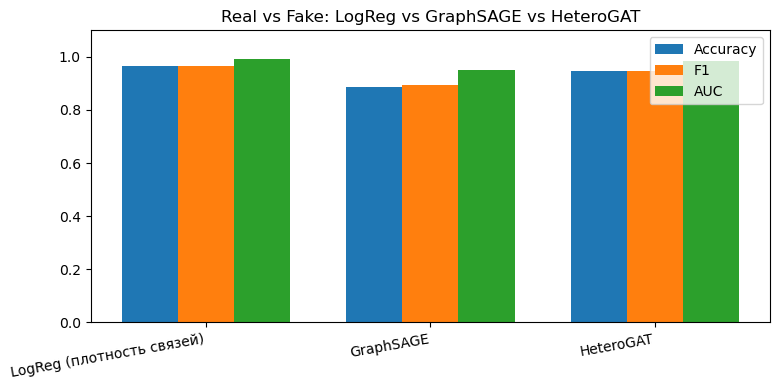

In [11]:
from sklearn.metrics import f1_score

comparison = pd.DataFrame([
    {'Модель': 'LogReg (плотность связей)',
     'Accuracy': accuracy_score(y_te, pred),
     'F1':       f1_score(y_te, pred, zero_division=0),
     'AUC':      roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])},
    {'Модель': 'GraphSAGE',
     'Accuracy': gs_result.accuracy,
     'F1':       gs_result.f1,
     'AUC':      gs_result.auc},
    {'Модель': 'HeteroGAT',
     'Accuracy': hg_val.accuracy,
     'F1':       hg_val.f1,
     'AUC':      hg_val.auc},
])
display(comparison.round(3))

x = np.arange(3)
w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w, comparison['Accuracy'], w, label='Accuracy')
ax.bar(x,     comparison['F1'],       w, label='F1')
ax.bar(x + w, comparison['AUC'],      w, label='AUC')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Модель'], rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title('Real vs Fake: LogReg vs GraphSAGE vs HeteroGAT')
plt.tight_layout()
plt.savefig(OUT / 'dish_validity_all_models.png', dpi=120)
plt.show()


## 3.10 Интерпретация: ингредиент-аутсайдер (структурная эвристика)

Графовая эвристика (**не** attention): для каждого фейкового рецепта показываем
1. Несовместимые пары (нет ребра в I)
2. Ингредиент с наименьшим числом общих соседей с остальными — «виновник»

Настоящие attention-веса модели — в §3.13.

In [12]:
def find_odd_ingredient(recipe_ings, I, top_k=3):
    """
    Находит ингредиент, наименее связанный с остальными.
    Метрика: среднее число общих соседей с каждым другим ингредиентом рецепта.
    """
    ings = [x for x in recipe_ings if x in I]
    if len(ings) < 2:
        return []
    scores = {}
    for ing in ings:
        others = [x for x in ings if x != ing]
        cn_sum = sum(
            len(set(I.neighbors(ing)) & set(I.neighbors(o)))
            for o in others
        )
        scores[ing] = cn_sum / len(others)
    return sorted(scores, key=scores.get)[:top_k]

print('── Интерпретация фейковых рецептов ──\n')
for i in range(5):
    r = fake[i]
    bad_pairs = incompatible_pairs(r, I)
    odd_ings  = find_odd_ingredient(r, I)

    print(f'Фейк #{i+1}: {ru_list(r[:8])}')
    print(f'  Плотность связей: {edge_density(r):.3f}')

    if bad_pairs:
        shown = [f'{ru(a)} + {ru(b)}' for a, b in bad_pairs[:3]]
        print(f'  Несовместимые пары ({len(bad_pairs)}): {", ".join(shown)}')

    if odd_ings:
        print(f'  Ингредиент-аутсайдер: {ru_list(odd_ings)}')
    print()


── Интерпретация фейковых рецептов ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', np.str_('orange soda'), np.str_('grain rice')]
  Плотность связей: 0.600
  Несовместимые пары (4): сливочное масло + orange soda, орехи + orange soda, орехи + grain rice
  Ингредиент-аутсайдер: [np.str_('orange soda'), np.str_('grain rice'), 'орехи']

Фейк #2: ['говядина', 'сметана', np.str_('lemonade mix'), np.str_('coconut instant pudding')]
  Плотность связей: 0.167
  Несовместимые пары (5): говядина + lemonade mix, говядина + coconut instant pudding, сметана + lemonade mix
  Ингредиент-аутсайдер: [np.str_('coconut instant pudding'), np.str_('lemonade mix'), 'говядина']

Фейк #3: ['перец', np.str_('garlic powder'), 'сливочное масло', np.str_('savoy'), np.str_("'s white chocolate"), np.str_('chop suey vegetables')]
  Плотность связей: 0.333
  Несовместимые пары (10): перец + savoy, перец + 's white chocolate, garlic powder + savoy
  Ингредиент-аутсайдер: [np.str_('savoy'), np.str_('chop s

## 3.11 Среднее структурных признаков ингредиентов + LogReg

Усредняем структурные признаки ингредиентов рецепта (из этапа 2) — это среднее **сырых** признаков (**не** GNN-pooling), затем LogReg.

Настоящий `global_mean_pool` по обученным эмбеддингам — в §3.14.

In [13]:
# feat_df уже загружен в ячейке 3.8 — используем его
FEAT_COLS = ['degree', 'degree_w', 'pagerank', 'clustering', 'kcore', 'betweenness', 'log_freq']

def mean_pool(ings, feat_df, cols):
    """Средний вектор признаков ингредиентов рецепта (global mean pool)."""
    valid = [x for x in ings if x in feat_df.index]
    if valid:
        return feat_df.loc[valid, cols].mean().values
    return np.zeros(len(cols))

X_pool = np.vstack([
    [mean_pool(r, feat_df, FEAT_COLS) for r in recipes],
    [mean_pool(r, feat_df, FEAT_COLS) for r in fake],
])

X_pool_tr, X_pool_te, ypool_tr, ypool_te = train_test_split(
    X_pool, y, test_size=0.2, random_state=42, stratify=y
)
clf_pool = LogisticRegression(max_iter=500)
clf_pool.fit(X_pool_tr, ypool_tr)
pred_pool = clf_pool.predict(X_pool_te)

pool_acc = accuracy_score(ypool_te, pred_pool)
pool_auc = roc_auc_score(ypool_te, clf_pool.predict_proba(X_pool_te)[:, 1])
print(f'MeanPool + LogReg:  acc={pool_acc:.3f}  AUC={pool_auc:.3f}')
print(classification_report(ypool_te, pred_pool, target_names=['фейк', 'реальный']))


MeanPool + LogReg:  acc=0.942  AUC=0.982
              precision    recall  f1-score   support

        фейк       0.94      0.94      0.94      1562
    реальный       0.94      0.94      0.94      1561

    accuracy                           0.94      3123
   macro avg       0.94      0.94      0.94      3123
weighted avg       0.94      0.94      0.94      3123



## 3.12 SHAP — почему рецепт фейк

SHAP объясняет предсказания MeanPool-модели: какой структурный признак ингредиентов  
сдвигает рецепт в сторону «фейк» или «реальный».

Затем для конкретного фейкового рецепта показываем, какой ингредиент «выбивается» сильнее всего.


/var/folders/t8/nykqdrg927vbm5cn8mrvgq1r0000gn/T/ipykernel_21652/666460511.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_pool_te[:200], feature_names=FEAT_COLS,


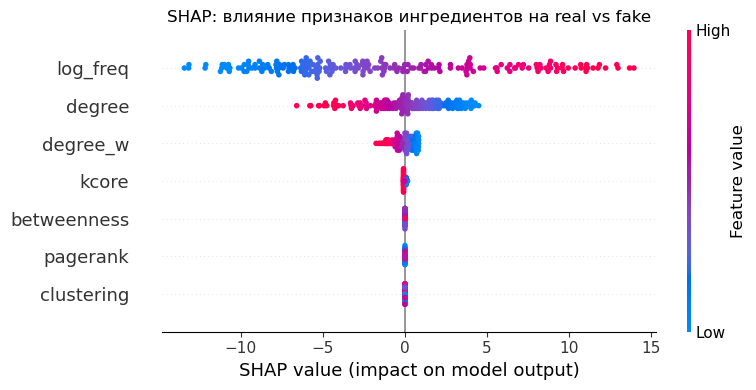

Фейк: ['сливочное масло', 'коричневый сахар', 'орехи', np.str_('orange soda'), np.str_('grain rice')]
Предсказание: фейк

SHAP-вклад каждого признака (+ = к реальному, − = к фейку):
  degree          -0.4565  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  log_freq        -0.2262  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  degree_w        -0.0518  █████████████████████████
  kcore           +0.0353  █████████████████
  betweenness     +0.0001  
  pagerank        -0.0000  
  clustering      +0.0000  


In [14]:
import shap

# LinearExplainer быстрее и точнее KernelExplainer для LogReg
explainer  = shap.LinearExplainer(clf_pool, X_pool_tr, feature_names=FEAT_COLS)
shap_vals  = explainer(X_pool_te[:200])

# Summary plot: глобальная важность признаков
shap.summary_plot(shap_vals, X_pool_te[:200], feature_names=FEAT_COLS,
                  show=False, plot_size=(8, 4))
plt.title('SHAP: влияние признаков ингредиентов на real vs fake')
plt.tight_layout()
plt.savefig(OUT / 'shap_summary.png', dpi=120)
plt.show()

# Объяснение для одного фейкового рецепта
i_explain = 0
x_fake_pool = mean_pool(fake[i_explain], feat_df, FEAT_COLS).reshape(1, -1)
sv_one = explainer(x_fake_pool)

print(f'Фейк: {ru_list(fake[i_explain][:8])}')
print(f'Предсказание: {"реальный" if clf_pool.predict(x_fake_pool)[0] == 1 else "фейк"}')
print()
print('SHAP-вклад каждого признака (+ = к реальному, − = к фейку):')
for feat, val in sorted(zip(FEAT_COLS, sv_one.values[0]), key=lambda x: abs(x[1]), reverse=True):
    bar = '█' * int(abs(val) * 500)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:<15} {sign}{abs(val):.4f}  {bar}')


## 3.13 Настоящие attention-веса HeteroGAT

В отличие от §3.10 (графовая эвристика по общим соседям), здесь мы читаем **реальные attention-веса** первого слоя HeteroGAT по рёбрам `ingredient → recipe` — насколько модель «слушает» каждый ингредиент при классификации рецепта. Это прямой, модельный ответ на вопрос «почему фейк».

In [15]:
# Настоящие attention-веса HeteroGAT (не эвристика, а веса самой модели)
from gnn_cuisine_classification import top_attention_ingredients

print('── Attention HeteroGAT: какие ингредиенты модель «слушает» ──\n')
n_real = len(recipes)
for k in range(3):
    ridx = n_real + k                      # индекс фейкового рецепта #k в data['recipe']
    top = top_attention_ingredients(
        hg_val.model, hg_val.data, ridx, hg_val.ing_names, top_k=5,
    )
    print(f'Фейк #{k+1}: {ru_list(fake[k][:8])}')
    for name, score in top:
        bar = '█' * int(score * 30)
        print(f'   attn={score:.3f} {bar} {ru(name)}')
    print()

── Attention HeteroGAT: какие ингредиенты модель «слушает» ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', np.str_('orange soda'), np.str_('grain rice')]
   attn=0.525 ███████████████ сливочное масло
   attn=0.143 ████ коричневый сахар
   attn=0.116 ███ орехи
   attn=0.108 ███ orange soda
   attn=0.108 ███ grain rice

Фейк #2: ['говядина', 'сметана', np.str_('lemonade mix'), np.str_('coconut instant pudding')]
   attn=0.351 ██████████ сметана
   attn=0.227 ██████ говядина
   attn=0.211 ██████ lemonade mix
   attn=0.210 ██████ coconut instant pudding

Фейк #3: ['перец', np.str_('garlic powder'), 'сливочное масло', np.str_('savoy'), np.str_("'s white chocolate"), np.str_('chop suey vegetables')]
   attn=0.499 ██████████████ сливочное масло
   attn=0.133 ███ перец
   attn=0.094 ██ garlic powder
   attn=0.092 ██ 's white chocolate
   attn=0.091 ██ chop suey vegetables



## 3.14 Настоящий `global_mean_pool` (GNN graph classification)

В отличие от §3.11 (среднее **сырых** признаков + LogReg), здесь `global_mean_pool` применяется к **обученным эмбеддингам ингредиентов** GraphSAGE-энкодера: рецепт → усреднённый graph-level вектор → классификатор. Это и есть «свёртка по всему графу рецепта», о которой говорил Илья.

In [16]:
import importlib, gnn_graph_classification
importlib.reload(gnn_graph_classification)
from gnn_graph_classification import train_graphsage_validity

gs_pool = train_graphsage_validity(
    all_recipes, y_all, I=I, hidden=64, epochs=50, seed=SEED, readout='mean',
)
print('GraphSAGE + global_mean_pool (real vs fake):')
print(f'  Accuracy: {gs_pool.accuracy:.3f}')
print(f'  F1:       {gs_pool.f1:.3f}')
print(f'  AUC:      {gs_pool.auc:.3f}')

GraphSAGE + global_mean_pool (real vs fake):
  Accuracy: 0.891
  F1:       0.895
  AUC:      0.959


## 3.15 Counterfactual: подмена/удаление ингредиента → рост P(фейк)

Именно то, что описывал Илья: берём обученную модель, по очереди **убираем** каждый ингредиент рецепта и смотрим, как меняется вероятность «фейк». Ингредиент, при удалении которого fake-вероятность **сильнее всего падает**, — и есть несочетаемый «виновник». Это модельная интерпретация на уровне конкретного ингредиента (в отличие от SHAP §3.12, который работает на уровне 7 усреднённых признаков).

In [17]:
from gnn_graph_classification import counterfactual_culprits

# используем модель с global_mean_pool (§3.14) — она чувствительнее к удалению ингредиента
print('── Counterfactual: убираем ингредиент → как меняется P(фейк) ──\n')
for k in range(3):
    base, culprits = counterfactual_culprits(gs_pool.model, fake[k], I)
    if base is None:
        continue
    print(f'Фейк #{k+1}: {ru_list(fake[k][:8])}')
    print(f'  P(фейк) исходно: {base:.3f}')
    for ing, delta in culprits[:3]:
        arrow = 'снижает фейк' if delta > 0 else 'повышает фейк'
        print(f'   убрать {ru(ing):<22} Δ={delta:+.3f}  ({arrow})')
    print()

── Counterfactual: убираем ингредиент → как меняется P(фейк) ──

Фейк #1: ['сливочное масло', 'коричневый сахар', 'орехи', np.str_('orange soda'), np.str_('grain rice')]
  P(фейк) исходно: 0.038
   убрать orange soda            Δ=+0.019  (снижает фейк)
   убрать grain rice             Δ=+0.012  (снижает фейк)
   убрать орехи                  Δ=-0.011  (повышает фейк)

Фейк #2: ['говядина', 'сметана', np.str_('lemonade mix'), np.str_('coconut instant pudding')]
  P(фейк) исходно: 0.086
   убрать coconut instant pudding Δ=+0.046  (снижает фейк)
   убрать lemonade mix           Δ=+0.032  (снижает фейк)
   убрать говядина               Δ=-0.056  (повышает фейк)

Фейк #3: ['перец', np.str_('garlic powder'), 'сливочное масло', np.str_('savoy'), np.str_("'s white chocolate"), np.str_('chop suey vegetables')]
  P(фейк) исходно: 0.216
   убрать savoy                  Δ=+0.113  (снижает фейк)
   убрать chop suey vegetables   Δ=+0.075  (снижает фейк)
   убрать 's white chocolate     Δ=+0.038  (сн